In [2]:
import requests
import pandas as pd 
import matplotlib.pyplot as plt
print("Libraries imported successfullly!")

Libraries imported successfullly!


In [6]:
url = "https://fakestoreapi.com/products"
response = requests.get(url)
data = response.json()
print("Data Fetched Sucessfully!")

Data Fetched Sucessfully!


In [7]:
df = pd.DataFrame(data)
df.head()

,id,title,price,description,category,image,rating
0,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",109.95,Your perfect pack for everyday use and walks i...,men's clothing,https://fakestoreapi.com/img/81fPKd-2AYL._AC_S...,"{'rate': 3.9, 'count': 120}"
1,2,Mens Casual Premium Slim Fit T-Shirts,22.30,"Slim-fitting style, contrast raglan long sleev...",men's clothing,https://fakestoreapi.com/img/71-3HjGNDUL._AC_S...,"{'rate': 4.1, 'count': 259}"
2,3,Mens Cotton Jacket,55.99,great outerwear jackets for Spring/Autumn/Wint...,men's clothing,https://fakestoreapi.com/img/71li-ujtlUL._AC_U...,"{'rate': 4.7, 'count': 500}"
3,4,Mens Casual Slim Fit,15.99,The color could be slightly different between ...,men's clothing,https://fakestoreapi.com/img/71YXzeOuslL._AC_U...,"{'rate': 2.1, 'count': 430}"
4,5,John Hardy Women's Legends Naga Gold & Silver ...,695.00,"From our Legends Collection, the Naga was insp...",jewelery,https://fakestoreapi.com/img/71pWzhdJNwL._AC_U...,"{'rate': 4.6, 'count': 400}"


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           20 non-null     int64  
 1   title        20 non-null     str    
 2   price        20 non-null     float64
 3   description  20 non-null     str    
 4   category     20 non-null     str    
 5   image        20 non-null     str    
 6   rating       20 non-null     object 
dtypes: float64(1), int64(1), object(1), str(4)
memory usage: 1.2+ KB


In [9]:
df.describe()

,id,price
count,20.00000,20.000000
mean,10.50000,162.046000
std,5.91608,272.220532
min,1.00000,7.950000
25%,5.75000,15.240000
50%,10.50000,56.490000
75%,15.25000,110.962500
max,20.00000,999.990000


In [10]:
df["price"].max()

np.float64(999.99)

In [12]:
df.shape

(20, 7)

In [13]:
df.isnull().sum()

id             0
title          0
price          0
description    0
category       0
image          0
rating         0
dtype: int64

In [15]:
df.drop(columns=["rating"]).duplicated().sum()

np.int64(0)

In [18]:
df["rate"] = df["rating"].apply(lambda x: x["rate"])
df["count"] = df["rating"].apply(lambda x: x["count"])
df.head()

,id,title,price,description,category,image,rating,rate,count
0,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",109.95,Your perfect pack for everyday use and walks i...,men's clothing,https://fakestoreapi.com/img/81fPKd-2AYL._AC_S...,"{'rate': 3.9, 'count': 120}",3.9,120
1,2,Mens Casual Premium Slim Fit T-Shirts,22.30,"Slim-fitting style, contrast raglan long sleev...",men's clothing,https://fakestoreapi.com/img/71-3HjGNDUL._AC_S...,"{'rate': 4.1, 'count': 259}",4.1,259
2,3,Mens Cotton Jacket,55.99,great outerwear jackets for Spring/Autumn/Wint...,men's clothing,https://fakestoreapi.com/img/71li-ujtlUL._AC_U...,"{'rate': 4.7, 'count': 500}",4.7,500
3,4,Mens Casual Slim Fit,15.99,The color could be slightly different between ...,men's clothing,https://fakestoreapi.com/img/71YXzeOuslL._AC_U...,"{'rate': 2.1, 'count': 430}",2.1,430
4,5,John Hardy Women's Legends Naga Gold & Silver ...,695.00,"From our Legends Collection, the Naga was insp...",jewelery,https://fakestoreapi.com/img/71pWzhdJNwL._AC_U...,"{'rate': 4.6, 'count': 400}",4.6,400


In [19]:
print("Total Product:",len(df))

Total Product: 20


In [21]:
df["category"].value_counts()

category
electronics         6
women's clothing    6
men's clothing      4
jewelery            4
Name: count, dtype: int64

In [24]:
df.groupby("category")["price"].mean()

category
electronics         332.498333
jewelery            220.995000
men's clothing       51.057500
women's clothing     26.286667
Name: price, dtype: float64

In [30]:
df.loc[df["price"].idxmax(), ["title","price","category"]]

title       Samsung 49-Inch CHG90 144Hz Curved Gaming Moni...
price                                                  999.99
category                                          electronics
Name: 13, dtype: object

In [33]:
df.loc[df["price"].idxmin(), ["title","price","category"]]

title       Opna Women's Short Sleeve Moisture
price                                     7.95
category                      women's clothing
Name: 18, dtype: object

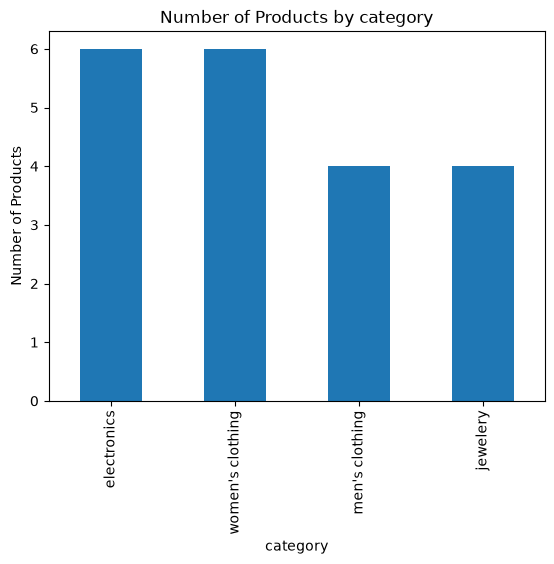

In [34]:
category_count = df["category"].value_counts()
category_count.plot(kind="bar")
plt.title("Number of Products by category")
plt.xlabel("category")
plt.ylabel("Number of Products")
plt.show()

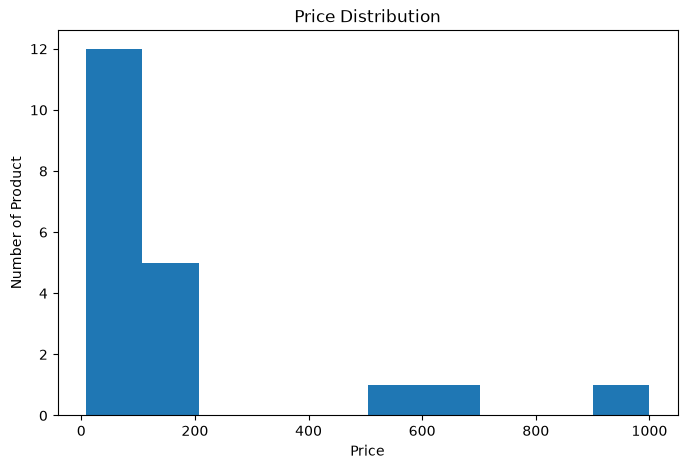

In [35]:
plt.figure(figsize=(8,5))
plt.hist(df["price"],bins=10)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Product")
plt.show()

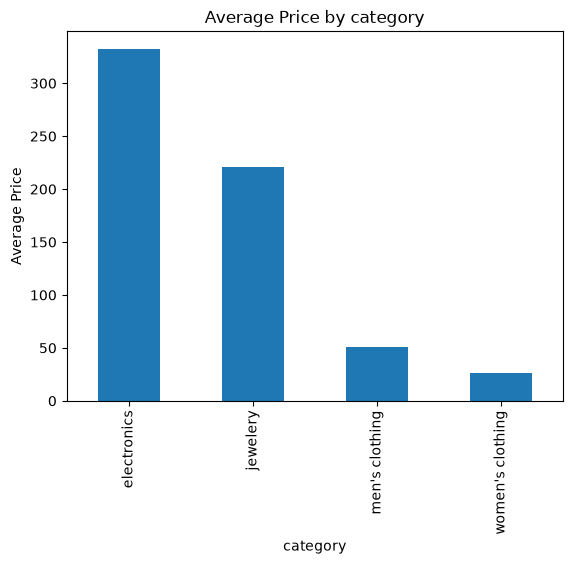

In [36]:
average_price = df.groupby("category")["price"].mean()
average_price.plot(kind="bar")
plt.title("Average Price by category")
plt.xlabel("category")
plt.ylabel("Average Price")
plt.show()

In [37]:
df.loc[df["rate"].idxmax(),["title","rate","category"]]

title       Silicon Power 256GB SSD 3D NAND A55 SLC Cache ...
rate                                                      4.8
category                                          electronics
Name: 10, dtype: object

In [38]:
df.loc[df["count"].idxmax(),["title","count","category"]]

title       Rain Jacket Women Windbreaker Striped Climbing...
count                                                     679
category                                     women's clothing
Name: 16, dtype: object

In [39]:
df.nlargest(5, "price")[["title","price","category"]]

,title,price,category
13,Samsung 49-Inch CHG90 144Hz Curved Gaming Moni...,999.99,electronics
4,John Hardy Women's Legends Naga Gold & Silver ...,695.00,jewelery
12,Acer SB220Q bi 21.5 inches Full HD (1920 x 108...,599.00,electronics
5,Solid Gold Petite Micropave,168.00,jewelery
11,WD 4TB Gaming Drive Works with Playstation 4 P...,114.00,electronics


#E-commerce Data Analysis using REST API

#E-commerce Data Analysis using REST API

In [1]:


print("1. The dataset contains products from multiple categories.")
print("2. Electronics contain some of the highest-priced products.")
print("3. Customer ratings help identify high-quality products.")
print("4. Review counts indicate product popularity.")
print("5. Visualizations make product trends easier to understand.")

1. The dataset contains products from multiple categories.
2. Electronics contain some of the highest-priced products.
3. Customer ratings help identify high-quality products.
4. Review counts indicate product popularity.
5. Visualizations make product trends easier to understand.


In [2]:


print("This project demonstrates how to fetch product data from a REST API,")
print("analyze it using Python and Pandas, and visualize the results")
print("to generate meaningful business insights.")

This project demonstrates how to fetch product data from a REST API,
analyze it using Python and Pandas, and visualize the results
to generate meaningful business insights.
